# Healthcare Access & Insurance Survey — Descriptive Analysis

This notebook explores a household survey dataset covering demographics, income,
health insurance coverage, hospital visits, routine check-ups, and cancer
screening behavior.

**Contents**
1. Setup & Data Loading
2. Data Overview & Quality Check
3. Data Cleaning
4. Demographics
5. Socioeconomic Profile
6. Health Insurance Coverage
7. Healthcare-Seeking Behavior (hospital visits, check-ups, screening)
8. Cross-Cutting Relationships
9. Key Findings Summary


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11
COLOR = '#2E6F95'
PALETTE = ['#2E6F95', '#E8A33D', '#7EB09B', '#C0574C', '#8E7CC3', '#5D8AA8', '#A9A9A9']

FILE_PATH = 'Healthcare_Dataset.xlsx'
df_raw = pd.read_excel(FILE_PATH)
print(f"Rows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}")
df_raw.head()


Rows: 6,158  |  Columns: 32


,Location,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,Date and Time,Age,Gender,Marital Status,"How many children do you have, if any?",Employment Status,Monthly Household Income,Have you ever had health insurance?,"If yes, which insurance cover?",When was the last time you visited a hospital for medical treatment? (In Months),Did you have health insurance during your last hospital visit?,Have you ever had a routine check-up with a doctor or healthcare provider?,"If you answered yes to the previous question, what time period (in years) do you stay before having your routine check-up?","Have you ever had a cancer screening (e.g. mammogram, colonoscopy, etc.)?","If you answered yes to the previous question, what time period (in years) do you stay before having your Cancer screening?",Your Picture,Your Picture_URL,_id,_uuid,_submission_time,_validation_status,_notes,_status,_submitted_by,__version__,_tags,_index
0,-0.2742007 36.058336 1882.2000732421875 20.0,-0.274201,36.058336,1882.200073,20.0,NaT,41-50,Female,Married,2.0,Self-employed,20001-30000,Yes,Nhif,53.0,No,Yes,2,No,2,NaN,NaN,230162389,aa30304f-84f2-4c1b-b30a-371241f2ff17,2023-04-05 08:44:06,NaN,NaN,submitted_via_web,NaN,vJ8gEKnN2pccxThc5jnkz4,NaN,1
1,-0.7158125 37.1475058 1361.9000244140625 20.0,-0.715812,37.147506,1361.900024,20.0,2023-05-15 13:38:00,18-30,Male,Single,0.0,Unemployed,Less than 10000,No,NaN,8.0,No,Yes,1,No,NaN,NaN,NaN,238299334,63c461e3-b3ef-47cf-9632-0c912a639f46,2023-05-15 10:44:01,NaN,NaN,submitted_via_web,safra_data,vMrCPR7NLZZJrf4PTsQ8uH,NaN,2
2,-0.7158157 37.1475082 1361.9000244140625 20.0,-0.715816,37.147508,1361.900024,20.0,2023-05-15 13:49:00,41-50,Female,Married,5.0,Self-employed,20001-30000,No,Nhif,6.0,Yes,No,NaN,Yes,4+,NaN,NaN,238301092,4209a55d-a983-433f-8ce0-bce6cd28d713,2023-05-15 10:51:08,NaN,NaN,submitted_via_web,safra_data,vMrCPR7NLZZJrf4PTsQ8uH,NaN,3
3,-0.7157082 37.14749 1361.9000244140625 20.0,-0.715708,37.147490,1361.900024,20.0,2023-05-15 14:19:00,18-30,Male,Single,NaN,Self-employed,10001-20000,Yes,Nhif,16.0,Yes,No,NaN,No,NaN,NaN,NaN,238311207,2eba9b13-1706-4faf-b7a7-e45e9dcf48ab,2023-05-15 11:22:19,NaN,NaN,submitted_via_web,safra_data,vMrCPR7NLZZJrf4PTsQ8uH,NaN,4
4,-0.7157337 37.1474799 1361.9000244140625 20.0,-0.715734,37.147480,1361.900024,20.0,2023-05-15 14:30:00,41-50,Male,Married,7.0,Self-employed,20001-30000,Yes,Nhif,13.0,Yes,No,NaN,Yes,4+,NaN,NaN,238314477,1f49cb82-75ff-4391-b69b-973a6ce698ee,2023-05-15 11:33:21,NaN,NaN,submitted_via_web,safra_data,vMrCPR7NLZZJrf4PTsQ8uH,NaN,5


## 2. Data Overview & Quality Check

The raw file includes survey-platform metadata columns (`_id`, `_uuid`,
`_submission_time`, `_index`, etc.) alongside the actual survey responses.
We first inspect structure, dtypes, and missingness before cleaning.

In [2]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 6158 entries, 0 to 6157
Data columns (total 32 columns):
 #   Column                                                                                                                      Non-Null Count  Dtype         
---  ------                                                                                                                      --------------  -----         
 0   Location                                                                                                                    5805 non-null   str           
 1   _Location_latitude                                                                                                          5805 non-null   float64       
 2   _Location_longitude                                                                                                         5805 non-null   float64       
 3   _Location_altitude                                                                                 

/tmp/ipykernel_605/4276933226.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


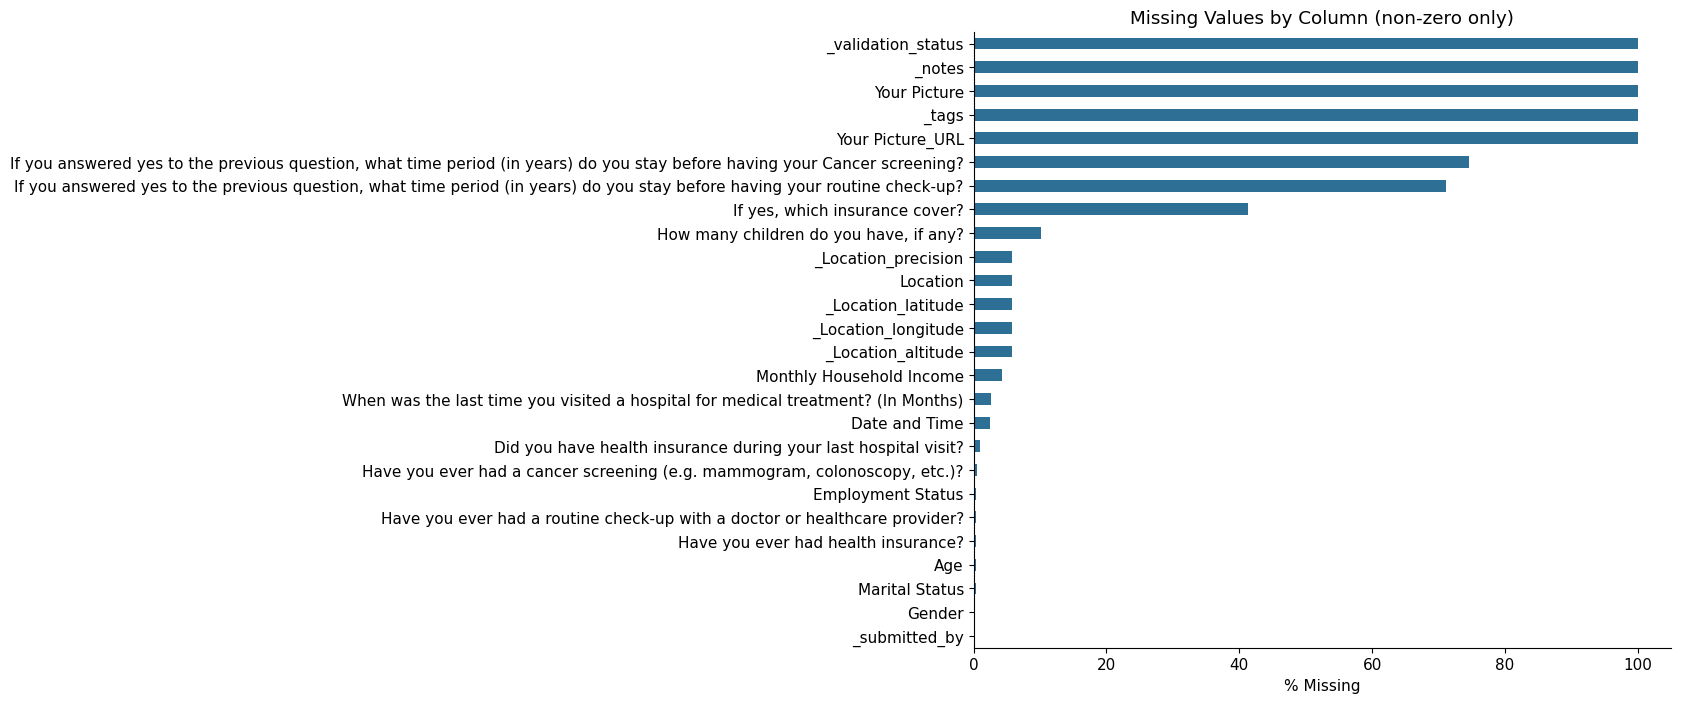

In [3]:
missing = df_raw.isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
fig, ax = plt.subplots(figsize=(9, 8))
missing.plot(kind='barh', ax=ax, color=COLOR)
ax.set_xlabel('% Missing')
ax.set_title('Missing Values by Column (non-zero only)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 3. Data Cleaning

Steps:
- Drop platform/metadata columns not relevant to descriptive analysis of survey content.
- Rename long survey-question columns to short, analysis-friendly names.
- Standardize the free-text "insurance cover" field (inconsistent capitalization/spacing).
- Set consistent category ordering for ordinal fields (Age, Income).


In [4]:
meta_cols = ['Location', '_Location_latitude', '_Location_longitude', '_Location_altitude',
             '_Location_precision', 'Your Picture', 'Your Picture_URL', '_id', '_uuid',
             '_validation_status', '_notes', '_status', '_submitted_by', '__version__',
             '_tags', '_index']

rename_map = {
    'Date and Time': 'survey_datetime',
    'Age': 'age_group',
    'Gender': 'gender',
    'Marital Status': 'marital_status',
    'How many children do you have, if any?': 'num_children',
    'Employment Status': 'employment_status',
    'Monthly Household Income': 'monthly_income',
    'Have you ever had health insurance?': 'ever_had_insurance',
    'If yes, which insurance cover?': 'insurance_provider',
    'When was the last time you visited a hospital for medical treatment? (In Months)': 'months_since_last_visit',
    'Did you have health insurance during your last hospital visit?': 'insured_at_last_visit',
    'Have you ever had a routine check-up with a doctor or healthcare provider?': 'ever_routine_checkup',
    'If you answered yes to the previous question, what time period (in years) do you stay before having your routine check-up?': 'checkup_frequency_years',
    'Have you ever had a cancer screening (e.g. mammogram, colonoscopy, etc.)?': 'ever_cancer_screening',
    'If you answered yes to the previous question, what time period (in years) do you stay before having your Cancer screening?': 'screening_frequency_years',
    '_submission_time': 'submission_time',
}

df = df_raw.drop(columns=meta_cols, errors='ignore').rename(columns=rename_map)

# Standardize free-text insurance provider names
def clean_provider(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x.lower() in ('null', 'none', 'n/a', 'na', ''):
        return np.nan
    return x.title()

df['insurance_provider_clean'] = df['insurance_provider'].apply(clean_provider)

# Ordered categories for readability in plots
age_order = ['18-30', '31-40', '41-50', '51-60', '60+']
income_order = ['Less than 10000', '10001-20000', '20001-30000', '30001-40000', '40001-50000', '50001+']
df['age_group'] = pd.Categorical(df['age_group'], categories=age_order, ordered=True)
df['monthly_income'] = pd.Categorical(df['monthly_income'], categories=income_order, ordered=True)

print(f"Cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Cleaned dataset: 6,158 rows x 17 columns


,survey_datetime,age_group,gender,marital_status,num_children,employment_status,monthly_income,ever_had_insurance,insurance_provider,months_since_last_visit,insured_at_last_visit,ever_routine_checkup,checkup_frequency_years,ever_cancer_screening,screening_frequency_years,submission_time,insurance_provider_clean
0,NaT,41-50,Female,Married,2.0,Self-employed,20001-30000,Yes,Nhif,53.0,No,Yes,2,No,2,2023-04-05 08:44:06,Nhif
1,2023-05-15 13:38:00,18-30,Male,Single,0.0,Unemployed,Less than 10000,No,NaN,8.0,No,Yes,1,No,NaN,2023-05-15 10:44:01,NaN
2,2023-05-15 13:49:00,41-50,Female,Married,5.0,Self-employed,20001-30000,No,Nhif,6.0,Yes,No,NaN,Yes,4+,2023-05-15 10:51:08,Nhif
3,2023-05-15 14:19:00,18-30,Male,Single,NaN,Self-employed,10001-20000,Yes,Nhif,16.0,Yes,No,NaN,No,NaN,2023-05-15 11:22:19,Nhif
4,2023-05-15 14:30:00,41-50,Male,Married,7.0,Self-employed,20001-30000,Yes,Nhif,13.0,Yes,No,NaN,Yes,4+,2023-05-15 11:33:21,Nhif


In [5]:
df.describe(include='all').T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
survey_datetime,6010,NaN,NaN,NaN,2023-06-23 12:19:03.484193,2023-05-15 08:35:00,2023-06-16 10:18:30,2023-06-23 10:22:00,2023-06-30 15:33:30,2023-07-27 12:00:00,NaN
age_group,6140,5,18-30,2183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,6141,2,Male,3107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,6140,3,Married,3654,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_children,5533.0,NaN,NaN,NaN,147.165371,0.0,1.0,2.0,3.0,800159.0,10757.08465
employment_status,6134,3,Employed,2177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_income,5899,6,Less than 10000,1837,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ever_had_insurance,6139,2,Yes,3558,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance_provider,3618,262,NHIF,1170,NaN,NaN,NaN,NaN,NaN,NaN,NaN
months_since_last_visit,6000.0,NaN,NaN,NaN,6.651875,0.0,2.0,4.0,8.0,2021.0,37.29553


## 4. Demographics

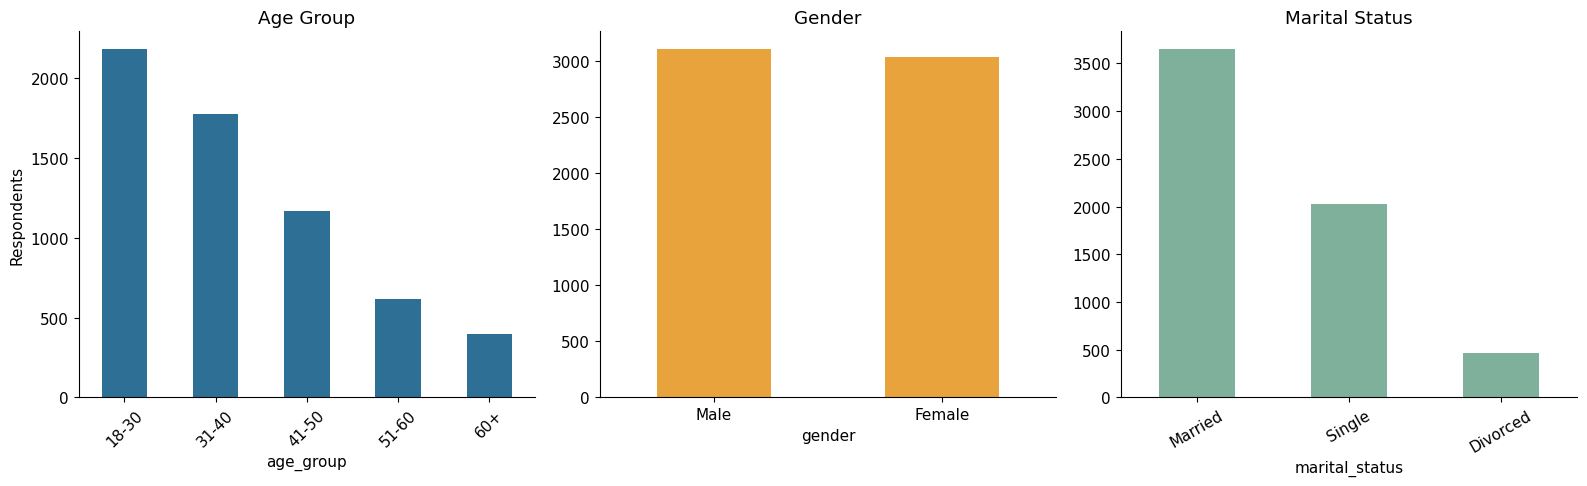

Age group %:
 age_group
18-30    35.6
31-40    28.9
41-50    19.0
51-60    10.1
60+       6.4
Name: proportion, dtype: float64

Gender %:
 gender
Male      50.6
Female    49.4
Name: proportion, dtype: float64

Marital status %:
 marital_status
Married     59.5
Single      33.0
Divorced     7.5
Name: proportion, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df['age_group'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=COLOR)
axes[0].set_title('Age Group')
axes[0].set_ylabel('Respondents')
axes[0].tick_params(axis='x', rotation=45)

df['gender'].value_counts().plot(kind='bar', ax=axes[1], color=PALETTE[1])
axes[1].set_title('Gender')
axes[1].tick_params(axis='x', rotation=0)

df['marital_status'].value_counts().plot(kind='bar', ax=axes[2], color=PALETTE[2])
axes[2].set_title('Marital Status')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("Age group %:\n", (df['age_group'].value_counts(normalize=True).sort_index()*100).round(1))
print("\nGender %:\n", (df['gender'].value_counts(normalize=True)*100).round(1))
print("\nMarital status %:\n", (df['marital_status'].value_counts(normalize=True)*100).round(1))


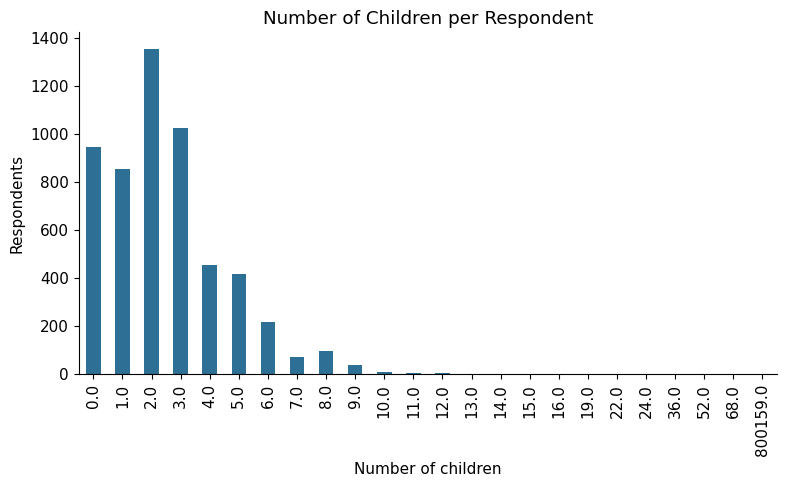

count      5533.000000
mean        147.165371
std       10757.084650
min           0.000000
25%           1.000000
50%           2.000000
75%           3.000000
max      800159.000000
Name: num_children, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
df['num_children'].value_counts().sort_index().plot(kind='bar', ax=ax, color=COLOR)
ax.set_title('Number of Children per Respondent')
ax.set_xlabel('Number of children')
ax.set_ylabel('Respondents')
plt.tight_layout()
plt.show()

print(df['num_children'].describe())


## 5. Socioeconomic Profile

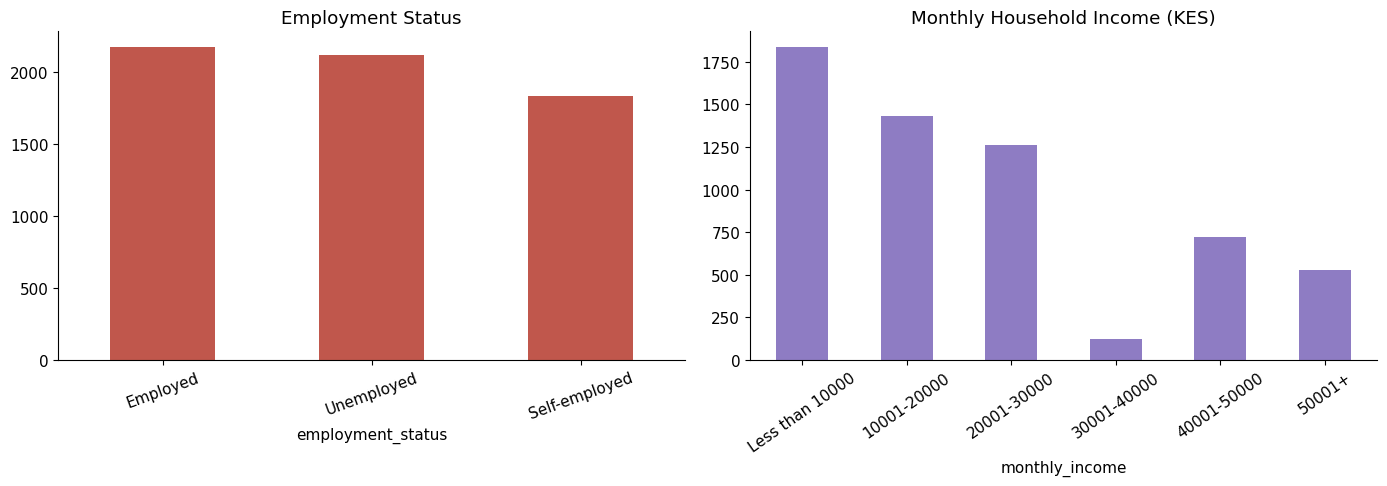

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['employment_status'].value_counts().plot(kind='bar', ax=axes[0], color=PALETTE[3])
axes[0].set_title('Employment Status')
axes[0].tick_params(axis='x', rotation=20)

df['monthly_income'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=PALETTE[4])
axes[1].set_title('Monthly Household Income (KES)')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()


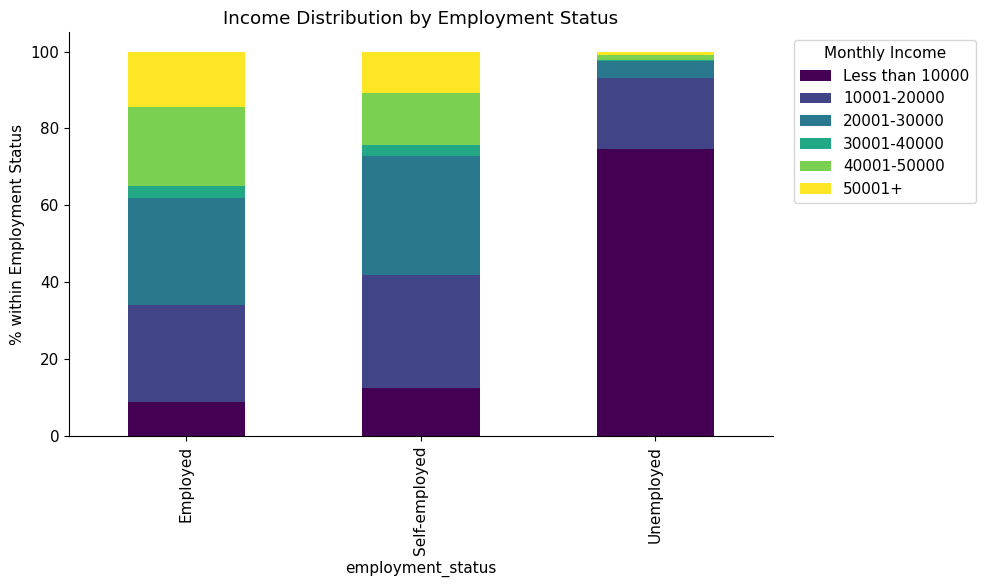

monthly_income,Less than 10000,10001-20000,20001-30000,30001-40000,40001-50000,50001+
employment_status,,,,,,
Employed,8.9,25.1,28.1,3.0,20.5,14.5
Self-employed,12.5,29.4,30.8,2.9,13.5,10.8
Unemployed,74.7,18.5,4.5,0.2,1.3,0.8


In [9]:
income_by_employment = pd.crosstab(df['employment_status'], df['monthly_income'], normalize='index') * 100
income_by_employment = income_by_employment[income_order]
income_by_employment.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Income Distribution by Employment Status')
plt.ylabel('% within Employment Status')
plt.legend(title='Monthly Income', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

income_by_employment.round(1)


## 6. Health Insurance Coverage

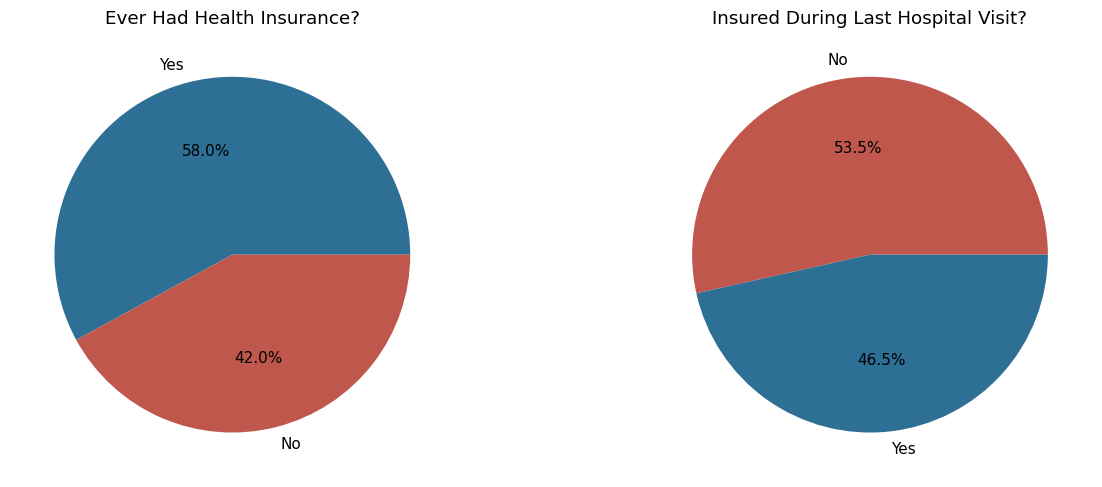

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['ever_had_insurance'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
                                              colors=[COLOR, PALETTE[3]], ylabel='')
axes[0].set_title('Ever Had Health Insurance?')

df['insured_at_last_visit'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                                 colors=[PALETTE[3], COLOR], ylabel='')
axes[1].set_title('Insured During Last Hospital Visit?')

plt.tight_layout()
plt.show()


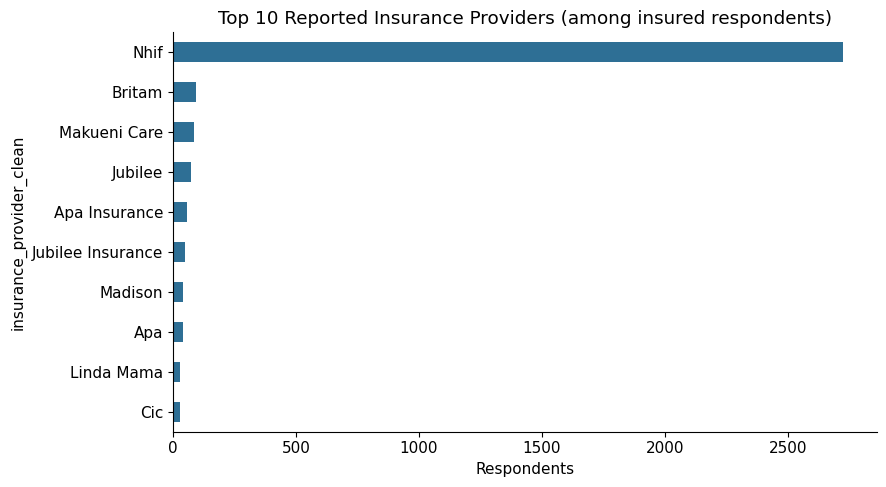

3,590 respondents named a provider; 2,725 (75.9%) named NHIF variants.


In [11]:
top_providers = df['insurance_provider_clean'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(9, 5))
top_providers.sort_values().plot(kind='barh', ax=ax, color=COLOR)
ax.set_title('Top 10 Reported Insurance Providers (among insured respondents)')
ax.set_xlabel('Respondents')
plt.tight_layout()
plt.show()

print(f"{df['insurance_provider_clean'].notna().sum():,} respondents named a provider; "
      f"{top_providers.iloc[0]:,} ({top_providers.iloc[0]/df['insurance_provider_clean'].notna().sum()*100:.1f}%) named NHIF variants.")


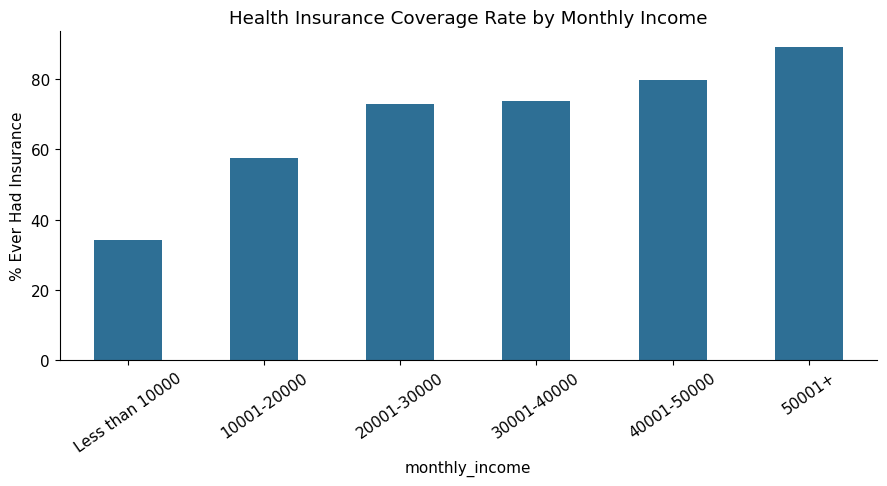

ever_had_insurance,No,Yes
monthly_income,,
Less than 10000,65.9,34.1
10001-20000,42.5,57.5
20001-30000,26.9,73.1
30001-40000,26.2,73.8
40001-50000,20.2,79.8
50001+,10.8,89.2


In [12]:
insurance_by_income = pd.crosstab(df['monthly_income'], df['ever_had_insurance'], normalize='index') * 100
insurance_by_income = insurance_by_income.reindex(income_order)
insurance_by_income['Yes'].plot(kind='bar', figsize=(9, 5), color=COLOR)
plt.title('Health Insurance Coverage Rate by Monthly Income')
plt.ylabel('% Ever Had Insurance')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

insurance_by_income.round(1)


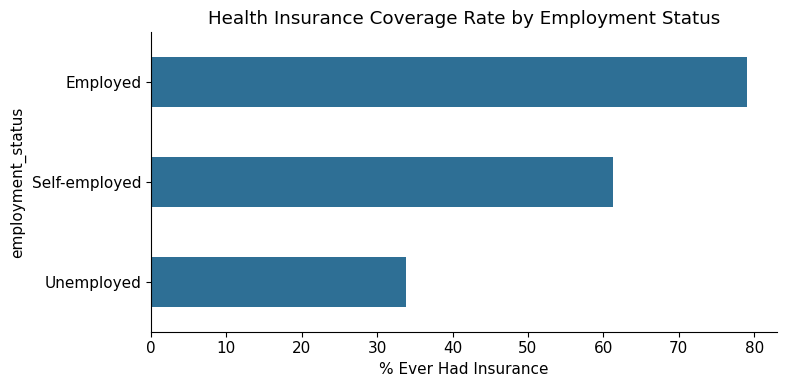

ever_had_insurance,No,Yes
employment_status,,
Employed,20.9,79.1
Self-employed,38.8,61.2
Unemployed,66.2,33.8


In [13]:
insurance_by_employment = pd.crosstab(df['employment_status'], df['ever_had_insurance'], normalize='index') * 100
insurance_by_employment['Yes'].sort_values().plot(kind='barh', figsize=(8, 4), color=COLOR)
plt.title('Health Insurance Coverage Rate by Employment Status')
plt.xlabel('% Ever Had Insurance')
plt.tight_layout()
plt.show()

insurance_by_employment.round(1)


## 7. Healthcare-Seeking Behavior

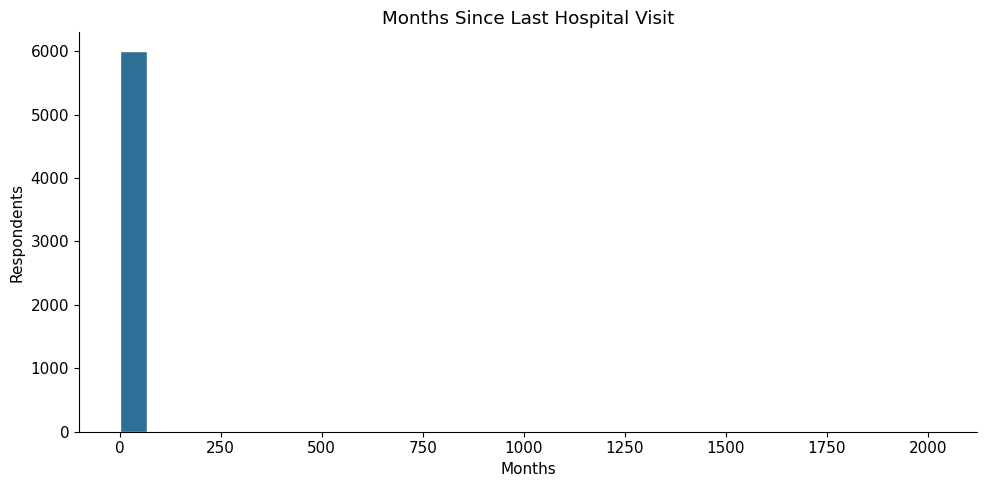

count    6000.000000
mean        6.651875
std        37.295530
min         0.000000
25%         2.000000
50%         4.000000
75%         8.000000
max      2021.000000
Name: months_since_last_visit, dtype: float64

Median: 4.0 months  |  75% visited within 8 months


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
df['months_since_last_visit'].dropna().plot(kind='hist', bins=30, ax=ax, color=COLOR, edgecolor='white')
ax.set_title('Months Since Last Hospital Visit')
ax.set_xlabel('Months')
ax.set_ylabel('Respondents')
plt.tight_layout()
plt.show()

print(df['months_since_last_visit'].describe())
print(f"\nMedian: {df['months_since_last_visit'].median():.1f} months  |  "
      f"75% visited within {df['months_since_last_visit'].quantile(0.75):.0f} months")


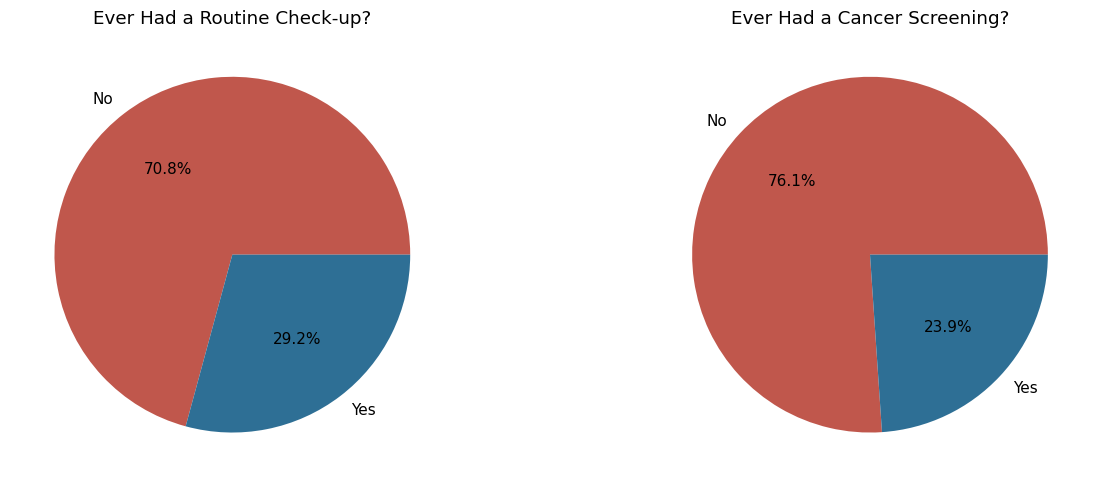

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['ever_routine_checkup'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
                                                colors=[PALETTE[3], COLOR], ylabel='')
axes[0].set_title('Ever Had a Routine Check-up?')

df['ever_cancer_screening'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                                 colors=[PALETTE[3], COLOR], ylabel='')
axes[1].set_title('Ever Had a Cancer Screening?')

plt.tight_layout()
plt.show()


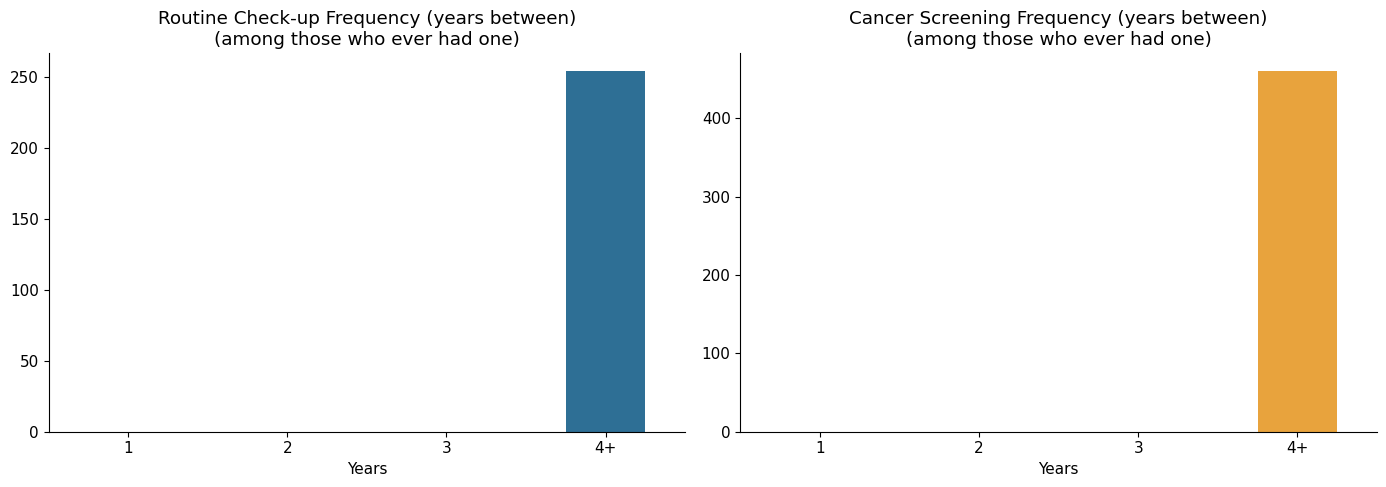

In [16]:
freq_order = ['1', '2', '3', '4+']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['checkup_frequency_years'].value_counts().reindex(freq_order).plot(kind='bar', ax=axes[0], color=COLOR)
axes[0].set_title('Routine Check-up Frequency (years between)\n(among those who ever had one)')
axes[0].set_xlabel('Years')
axes[0].tick_params(axis='x', rotation=0)

df['screening_frequency_years'].value_counts().reindex(freq_order).plot(kind='bar', ax=axes[1], color=PALETTE[1])
axes[1].set_title('Cancer Screening Frequency (years between)\n(among those who ever had one)')
axes[1].set_xlabel('Years')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 8. Cross-Cutting Relationships

Do insured respondents engage in more preventive care (routine check-ups,
cancer screening) than uninsured respondents? Does check-up behavior vary by age?

Routine check-up rate by insurance status:
ever_routine_checkup    No   Yes
ever_had_insurance              
No                    85.4  14.6
Yes                   60.2  39.8

Cancer screening rate by insurance status:
ever_cancer_screening    No   Yes
ever_had_insurance               
No                     88.5  11.5
Yes                    67.0  33.0


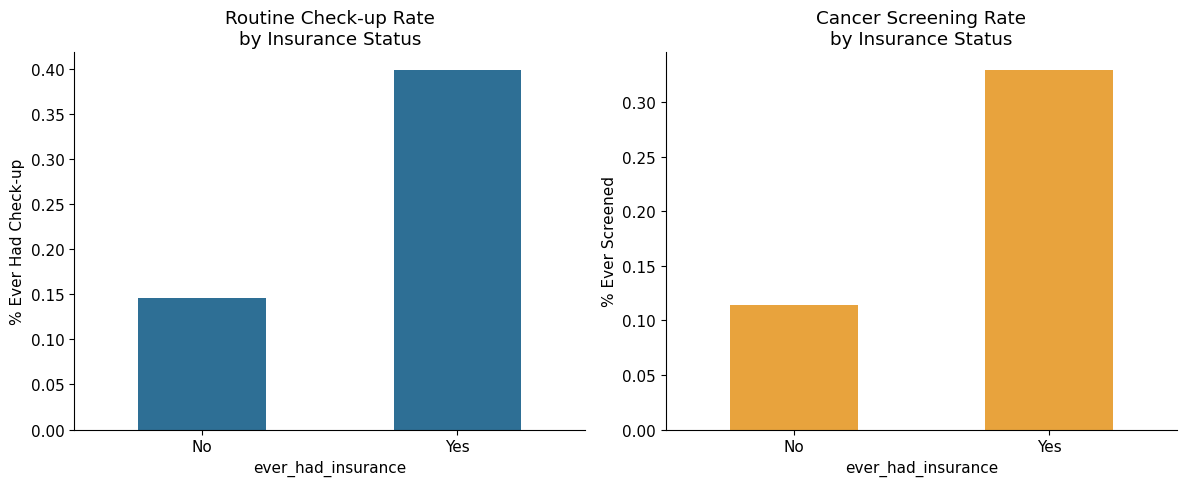

In [17]:
preventive_by_insurance = pd.crosstab(df['ever_had_insurance'], 
                                       [df['ever_routine_checkup'], df['ever_cancer_screening']],
                                       normalize='index') * 100
print("Routine check-up rate by insurance status:")
print((pd.crosstab(df['ever_had_insurance'], df['ever_routine_checkup'], normalize='index')*100).round(1))
print("\nCancer screening rate by insurance status:")
print((pd.crosstab(df['ever_had_insurance'], df['ever_cancer_screening'], normalize='index')*100).round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pd.crosstab(df['ever_had_insurance'], df['ever_routine_checkup'], normalize='index')['Yes'].plot(
    kind='bar', ax=axes[0], color=COLOR)
axes[0].set_title('Routine Check-up Rate\nby Insurance Status')
axes[0].set_ylabel('% Ever Had Check-up')
axes[0].tick_params(axis='x', rotation=0)

pd.crosstab(df['ever_had_insurance'], df['ever_cancer_screening'], normalize='index')['Yes'].plot(
    kind='bar', ax=axes[1], color=PALETTE[1])
axes[1].set_title('Cancer Screening Rate\nby Insurance Status')
axes[1].set_ylabel('% Ever Screened')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


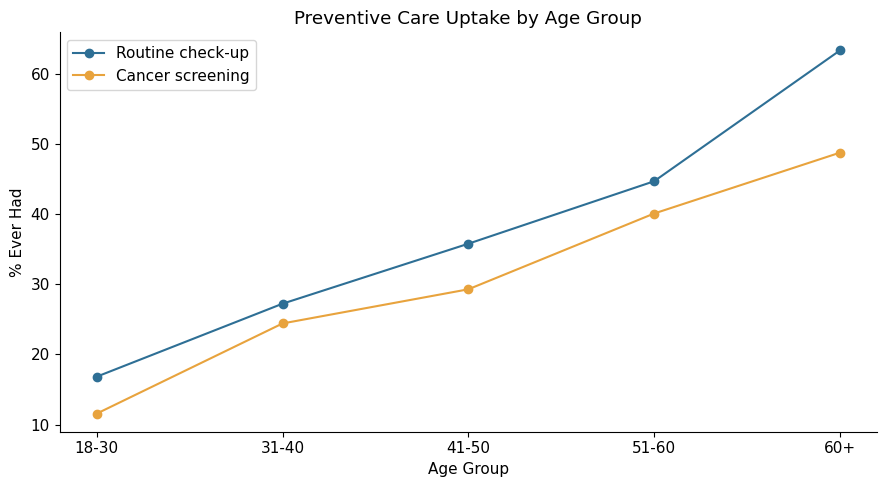

In [18]:
checkup_by_age = pd.crosstab(df['age_group'], df['ever_routine_checkup'], normalize='index') * 100
checkup_by_age = checkup_by_age.reindex(age_order)
screening_by_age = pd.crosstab(df['age_group'], df['ever_cancer_screening'], normalize='index') * 100
screening_by_age = screening_by_age.reindex(age_order)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(age_order, checkup_by_age['Yes'], marker='o', label='Routine check-up', color=COLOR)
ax.plot(age_order, screening_by_age['Yes'], marker='o', label='Cancer screening', color=PALETTE[1])
ax.set_title('Preventive Care Uptake by Age Group')
ax.set_ylabel('% Ever Had')
ax.set_xlabel('Age Group')
ax.legend()
plt.tight_layout()
plt.show()


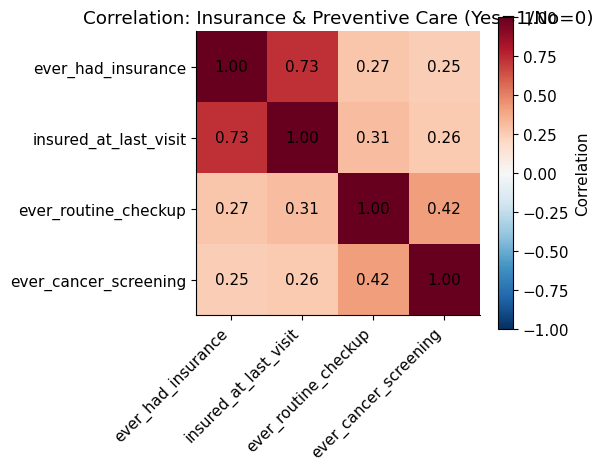

In [19]:
corr_source = df[['ever_had_insurance', 'insured_at_last_visit', 'ever_routine_checkup', 'ever_cancer_screening']].copy()
for c in corr_source.columns:
    corr_source[c] = corr_source[c].map({'Yes': 1, 'No': 0})

corr = corr_source.corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', color='black')
plt.colorbar(im, label='Correlation')
plt.title('Correlation: Insurance & Preventive Care (Yes=1/No=0)')
plt.tight_layout()
plt.show()


## 9. Key Findings Summary

Run the cell below to print an auto-generated summary of headline statistics
from the sections above.

In [20]:
n = len(df)
pct_insured = (df['ever_had_insurance'] == 'Yes').mean() * 100
pct_insured_last_visit = (df['insured_at_last_visit'] == 'Yes').mean() * 100
pct_checkup = (df['ever_routine_checkup'] == 'Yes').mean() * 100
pct_screening = (df['ever_cancer_screening'] == 'Yes').mean() * 100
median_months = df['months_since_last_visit'].median()
top_income_bracket = df['monthly_income'].value_counts(normalize=True).idxmax()

checkup_insured = (df.loc[df['ever_had_insurance']=='Yes', 'ever_routine_checkup']=='Yes').mean()*100
checkup_uninsured = (df.loc[df['ever_had_insurance']=='No', 'ever_routine_checkup']=='Yes').mean()*100

print(f"""HEADLINE STATISTICS  (n = {n:,} respondents)
{'-'*55}
Demographics
  - Modal age group: {df['age_group'].value_counts().idxmax()} ({df['age_group'].value_counts(normalize=True).max()*100:.1f}%)
  - Gender split: {(df['gender'].value_counts(normalize=True)*100).round(1).to_dict()}
  - Most common marital status: {df['marital_status'].value_counts().idxmax()}

Socioeconomic
  - Most common income bracket: {top_income_bracket}
  - Employment status split: {(df['employment_status'].value_counts(normalize=True)*100).round(1).to_dict()}

Insurance Coverage
  - {pct_insured:.1f}% have EVER had health insurance
  - {pct_insured_last_visit:.1f}% were insured during their LAST hospital visit
  - Most cited provider: NHIF (national scheme) and its variants

Healthcare-Seeking Behavior
  - Median time since last hospital visit: {median_months:.0f} months
  - {pct_checkup:.1f}% have ever had a routine check-up
  - {pct_screening:.1f}% have ever had a cancer screening

Insurance & Preventive Care Link
  - Routine check-up rate among INSURED: {checkup_insured:.1f}%
  - Routine check-up rate among UNINSURED: {checkup_uninsured:.1f}%
  - Gap: {checkup_insured - checkup_uninsured:+.1f} percentage points
""")


HEADLINE STATISTICS  (n = 6,158 respondents)
-------------------------------------------------------
Demographics
  - Modal age group: 18-30 (35.6%)
  - Gender split: {'Male': 50.6, 'Female': 49.4}
  - Most common marital status: Married

Socioeconomic
  - Most common income bracket: Less than 10000
  - Employment status split: {'Employed': 35.5, 'Unemployed': 34.6, 'Self-employed': 29.9}

Insurance Coverage
  - 57.8% have EVER had health insurance
  - 46.1% were insured during their LAST hospital visit
  - Most cited provider: NHIF (national scheme) and its variants

Healthcare-Seeking Behavior
  - Median time since last hospital visit: 4 months
  - 29.1% have ever had a routine check-up
  - 23.8% have ever had a cancer screening

Insurance & Preventive Care Link
  - Routine check-up rate among INSURED: 39.8%
  - Routine check-up rate among UNINSURED: 14.5%
  - Gap: +25.2 percentage points



### Interpretation

- **Insurance coverage is moderate** (roughly 58% have ever held insurance), dominated
  by Kenya's national scheme (NHIF and its variants), with private insurers
  (Britam, Jubilee, APA, Madison, AAR) each covering a small share.
- **Preventive care is underused**: routine check-ups and cancer screening are
  reported by a minority of respondents, even though insured respondents are
  noticeably more likely to have had a check-up than uninsured respondents —
  consistent with insurance reducing financial barriers to preventive care.
- **Income and employment shape access**: higher income brackets skew toward
  higher insurance coverage, and the majority of respondents fall in the
  lower income brackets, suggesting affordability is a plausible barrier to
  both insurance uptake and preventive care.
- These are descriptive/associational patterns only — no causal claims should
  be drawn from cross-tabulations alone.
